In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [2]:
# 데이터 생성
dataset = pd.read_csv('로지스틱_자격증.csv')

In [3]:
# 독립 변수와 종속 변수 분리 

X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [4]:
# 훈련, 테스트 분리(섞어서 행 분리)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
# 학습
classfier = LogisticRegression()
classfier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
# 예측
# 6시간, 4시간 학습했을 때 예측?
print(classfier.predict([[6], [4]]))
# 불합격 확률, 합격 확률
print(classfier.predict_proba([[6], [4]]))

# 분류 결과(테스트 세트)
print(X_test.values)
y_pred = classfier.predict(X_test)
print(y_pred) # 예측
print(y_test.values) # 실제

[1 0]
[[0.09632358 0.90367642]
 [0.64649891 0.35350109]]
[[3.9]
 [5.8]
 [8.4]
 [4.4]]
[0 1 1 0]
[0 0 1 1]


c:\Users\hi6\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\hi6\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


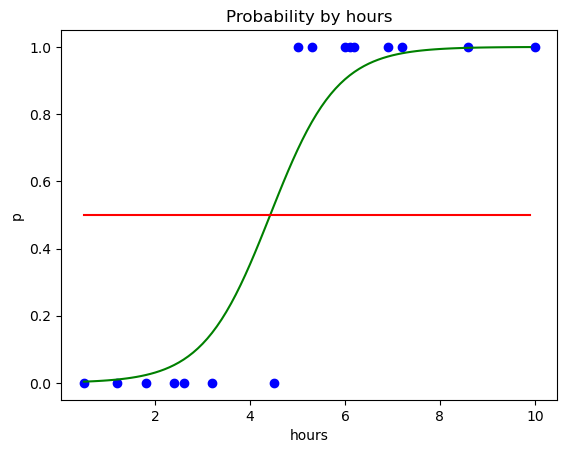

In [7]:
# 시각화
x_range = np.arange(X.min().item(), X.max().item(), 0.1)
# p = 1 / ( 1 + np.exp(-y)) # y = mx + b
p = 1 / ( 1 + np.exp(-(classfier.coef_ * x_range + classfier.intercept_)))
# p는 1행 95열인 2차원 배열
# x_range는 95개 1차원 배열
p = p.reshape(-1) # 또는 -1

plt.scatter(X_train, y_train, color='blue')
plt.plot(x_range, p, color='green')
plt.plot(x_range, np.full(len(x_range), 0.5), color='red') # x_range개수만큼 0.5로 채운 선을 만듬
plt.title('Probability by hours')
plt.xlabel('hours')
plt.ylabel('p')
plt.show()

In [8]:
# 혼동행렬
# 혼돈 행렬(Confusion Matrix)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(X_test.values.tolist())
print(f'예측 : {y_pred}')
print(f'실제 : {y_test.values}')
print('혼돈행렬 : ')
print(cm)

[[3.9], [5.8], [8.4], [4.4]]
예측 : [0 1 1 0]
실제 : [0 0 1 1]
혼돈행렬 : 
[[1 1]
 [1 1]]
